In [1]:
# Titanic Survival Prediction with Workflow

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#Load Titanic Dataset

In [4]:
titanic = pd.read_csv("train.csv")

In [5]:
print("Shape:", titanic.shape)
titanic.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
titanic.info(), titanic.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


(None,
        PassengerId    Survived      Pclass         Age       SibSp  \
 count   891.000000  891.000000  891.000000  714.000000  891.000000   
 mean    446.000000    0.383838    2.308642   29.699118    0.523008   
 std     257.353842    0.486592    0.836071   14.526497    1.102743   
 min       1.000000    0.000000    1.000000    0.420000    0.000000   
 25%     223.500000    0.000000    2.000000   20.125000    0.000000   
 50%     446.000000    0.000000    3.000000   28.000000    0.000000   
 75%     668.500000    1.000000    3.000000   38.000000    1.000000   
 max     891.000000    1.000000    3.000000   80.000000    8.000000   
 
             Parch        Fare  
 count  891.000000  891.000000  
 mean     0.381594   32.204208  
 std      0.806057   49.693429  
 min      0.000000    0.000000  
 25%      0.000000    7.910400  
 50%      0.000000   14.454200  
 75%      0.000000   31.000000  
 max      6.000000  512.329200  )

In [7]:
#Data Cleaning

In [32]:
# Fill missing Age with median
titanic["Age"].fillna(titanic["Age"].median())
# median is used for numerical data since it is less affected by outliers than mean.

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [28]:
titanic["Embarked"].fillna(titanic["Embarked"].mode()[0])
#mode is used for categorical data (most common port). 

0      2
1      0
2      2
3      2
4      2
      ..
886    2
887    2
888    2
889    0
890    1
Name: Embarked, Length: 891, dtype: int64

In [10]:
titanic.drop("Cabin", axis=1, inplace=True)
#cabin has too many missing values therefore, the column is dropped for simplicity

In [11]:
titanic.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [12]:
#Feature Encoding 

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [14]:
titanic["Sex"] = titanic["Sex"].map({"female": 0, "male": 1}) #encode sex (male/female to 0/1)

In [15]:
le = LabelEncoder()
titanic["Sex"] = le.fit_transform(titanic["Sex"])
titanic["Embarked"] = le.fit_transform(titanic["Embarked"])
# Encode Embarked (C, Q, S to 0, 1, 2)

In [16]:
# Train-test split
X = titanic[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]]
y = titanic["Survived"]

In [17]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2, random_state= 42)

In [18]:
X_train.shape, X_test.shape

((712, 7), (179, 7))

In [19]:
import seaborn as sns #EDA

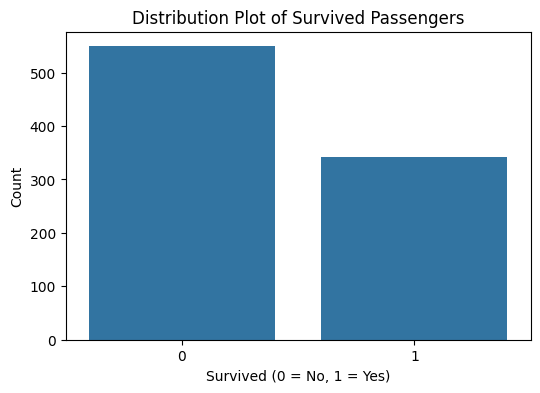

In [30]:
plt.figure(figsize=(6,4))
sns.countplot(x="Survived", data=titanic)
plt.title("Distribution Plot of Survived Passengers")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

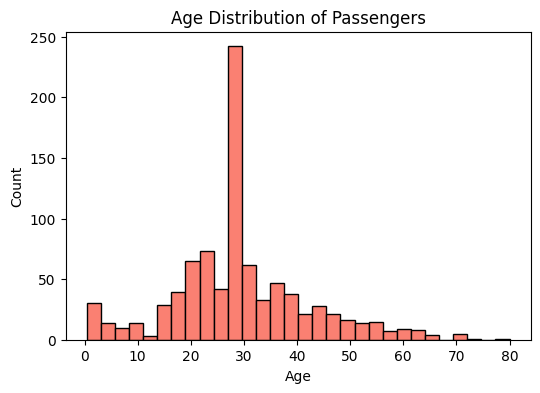

In [21]:
plt.figure(figsize=(6,4))
plt.hist(titanic["Age"], bins=30, color="salmon", edgecolor="black")
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

In [22]:
# Supervised Learning
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.cluster import KMeans

In [23]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [24]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8100558659217877

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [25]:
# Unsupervised Learning
from sklearn.cluster import KMeans
X = titanic[["Age", "Fare", "Pclass"]].dropna()

clusters = KMeans(n_clusters=3, random_state=42).fit_predict(X)


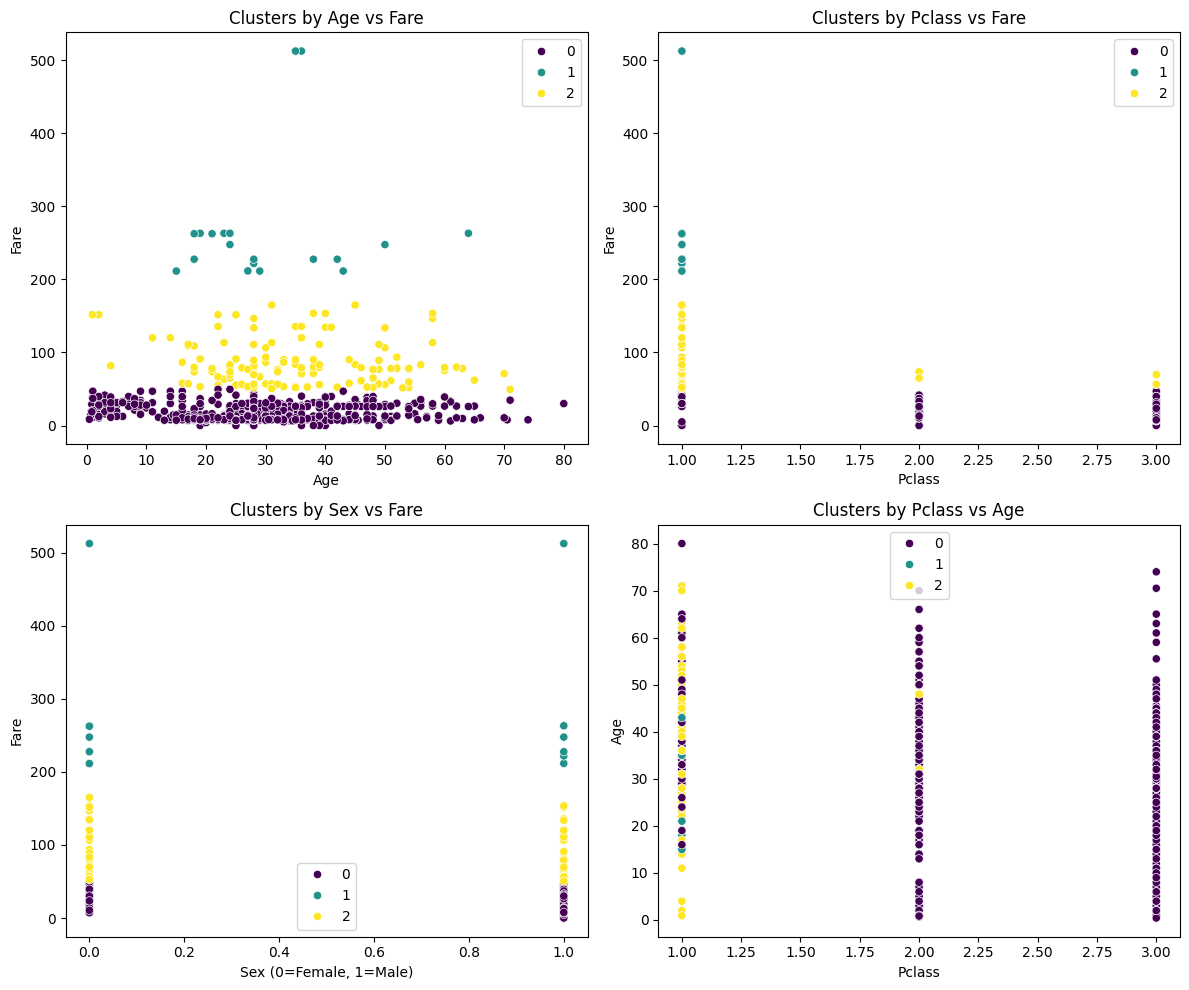

In [26]:
from sklearn.cluster import KMeans

fig, axes = plt.subplots(2, 2, figsize=(12, 10))  # 2 rows, 2 cols

# Plot 1: Age vs Fare
sns.scatterplot(
    x=titanic["Age"], y=titanic["Fare"],
    hue=clusters, palette="viridis", ax=axes[0,0]
)
axes[0,0].set_title("Clusters by Age vs Fare")

# Plot 2: Pclass vs Fare
sns.scatterplot(
    x=titanic["Pclass"], y=titanic["Fare"],
    hue=clusters, palette="viridis", ax=axes[0,1]
)
axes[0,1].set_title("Clusters by Pclass vs Fare")

# Plot 3: Sex vs Fare
sns.scatterplot(
    x=titanic["Sex"], y=titanic["Fare"],
    hue=clusters, palette="viridis", ax=axes[1,0]
)
axes[1,0].set_title("Clusters by Sex vs Fare")
axes[1,0].set_xlabel("Sex (0=Female, 1=Male)")

# Plot 4: Pclass vs Age
sns.scatterplot(
    x=titanic["Pclass"], y=titanic["Age"],
    hue=clusters, palette="viridis", ax=axes[1,1]
)
axes[1,1].set_title("Clusters by Pclass vs Age")

plt.tight_layout()
plt.show()

In [31]:
#Evaluation
log_model = LogisticRegression(max_iter=500)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

# Decision Tree
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

In [ ]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))


Logistic Regression Accuracy: 0.8100558659217877
Decision Tree Accuracy: 0.7821229050279329
